In [1]:
import os

base_dir = r"C:\Projects\GUVI_Pro\SolarPanel_Detection\Faulty_solar_panel"

print("Dataset Location:")
print(base_dir)

print("\nFolder Exists:", os.path.exists(base_dir))
print(f"Scanning all contents inside: {base_dir}\n")

total_images_found = 0

for root, dirs, files in os.walk(base_dir):
    img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

    if len(img_files) > 0:
        print(f"SUCCESS: Found {len(img_files)} images in folder -> {root}")
        print(f"  Sample files: {img_files[:3]}\n")
        total_images_found += len(img_files)
    elif len(dirs) > 0:
        print(f"Explored '{root}' -> Found sub-folders: {dirs}")

print(f"\nTotal images found across all folders: {total_images_found}")

Dataset Location:
C:\Projects\GUVI_Pro\SolarPanel_Detection\Faulty_solar_panel

Folder Exists: True
Scanning all contents inside: C:\Projects\GUVI_Pro\SolarPanel_Detection\Faulty_solar_panel

Explored 'C:\Projects\GUVI_Pro\SolarPanel_Detection\Faulty_solar_panel' -> Found sub-folders: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
SUCCESS: Found 191 images in folder -> C:\Projects\GUVI_Pro\SolarPanel_Detection\Faulty_solar_panel\Bird-drop
  Sample files: ['Bird (1).jpeg', 'Bird (10).jpg', 'Bird (100).jpg']

SUCCESS: Found 16 images in folder -> C:\Projects\GUVI_Pro\SolarPanel_Detection\Faulty_solar_panel\Bird-drop\New
  Sample files: ['1.JPG', '10.JPG', '11.JPG']

SUCCESS: Found 193 images in folder -> C:\Projects\GUVI_Pro\SolarPanel_Detection\Faulty_solar_panel\Clean
  Sample files: ['Clean (1).jpeg', 'Clean (10).JPG', 'Clean (100).jpg']

SUCCESS: Found 190 images in folder -> C:\Projects\GUVI_Pro\SolarPanel_Detection\Faulty_solar_panel\Dusty
 

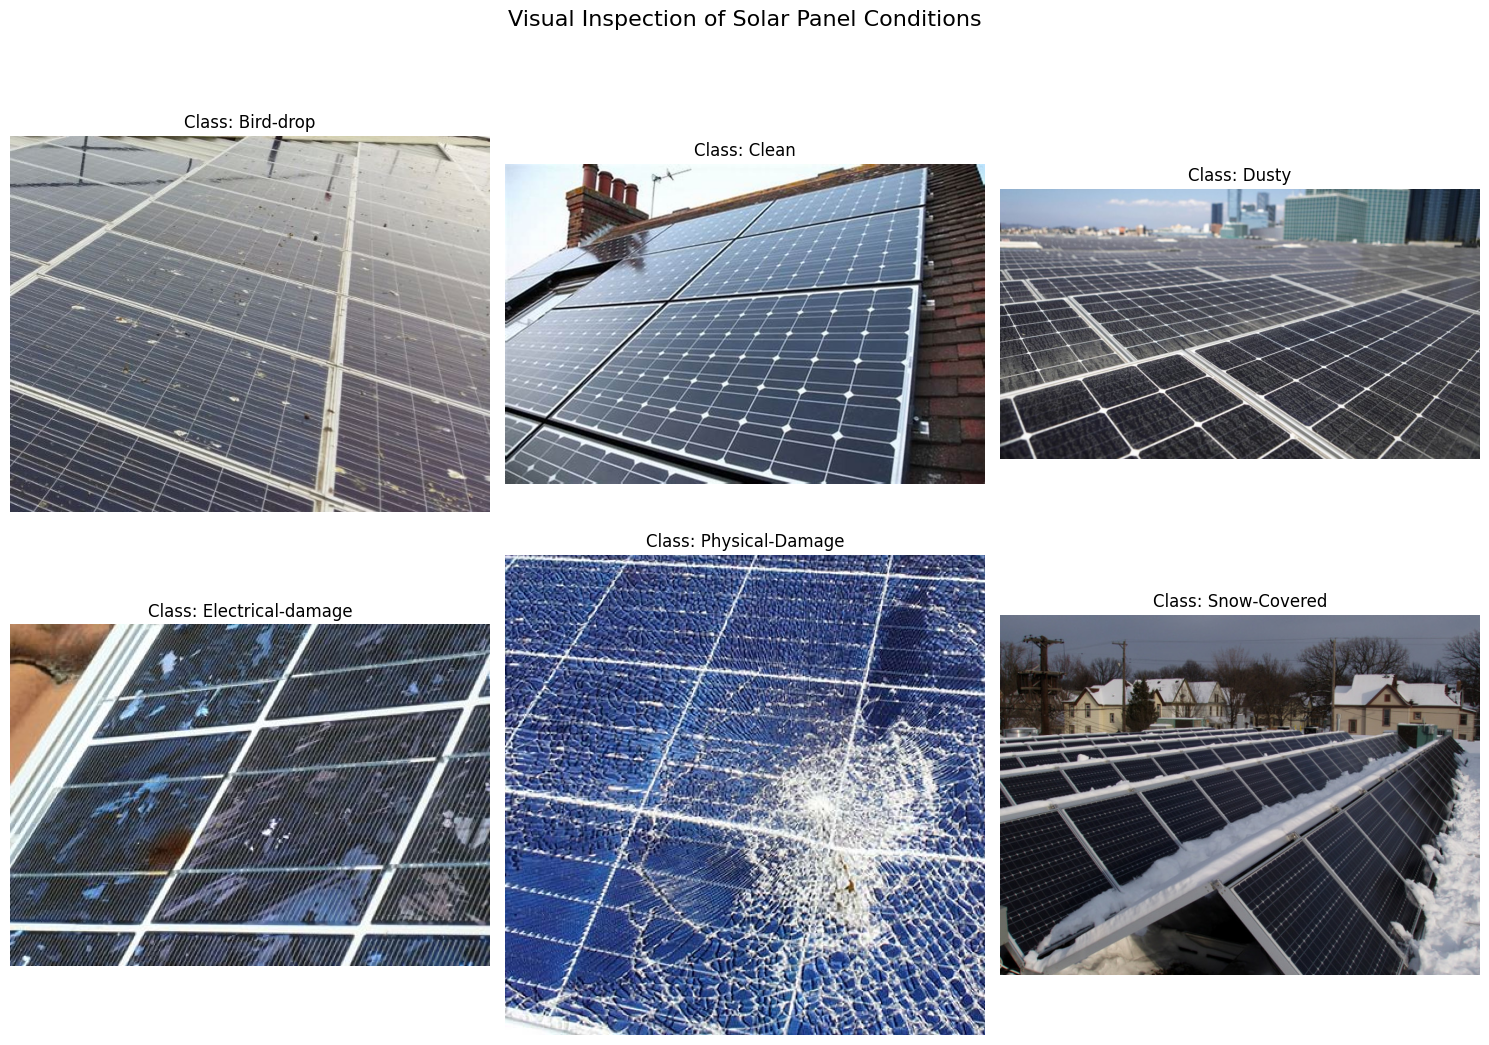

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

plt.figure(figsize=(15, 10))
for i, cls in enumerate(classes):
    cls_path = os.path.join(base_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if images:
        random_image = random.choice(images)
        img_path = os.path.join(cls_path, random_image)

        img = mpimg.imread(img_path)
        plt.subplot(2, 3, i + 1) # 2 rows, 3 columns for your 6 classes
        plt.imshow(img)
        plt.title(f"Class: {cls}")
        plt.axis('off')

plt.tight_layout()
plt.suptitle("Visual Inspection of Solar Panel Conditions", y=1.05, fontsize=16)
plt.show()

In [3]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Initializing Training Dataset...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' 
)

print("\nInitializing Validation Dataset...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f"\nMapped Classes: {class_names}")

Initializing Training Dataset...
Found 885 files belonging to 6 classes.
Using 708 files for training.

Initializing Validation Dataset...
Found 885 files belonging to 6 classes.
Using 177 files for validation.

Mapped Classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


In [4]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

normalized_train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
normalized_val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = normalized_train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = normalized_val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\nData preprocessing complete. Tensors are normalized and optimized for training.")


Data preprocessing complete. Tensors are normalized and optimized for training.


In [5]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
])

model = models.Sequential([

    layers.InputLayer(input_shape=(224, 224, 3)),
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),


    layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),


    layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),


    layers.Flatten(),


    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Randomly turns off 50% of neurons to prevent overfitting

 
    layers.Dense(6, activation='softmax')
])

model.summary()

c:\Projects\GUVI_Pro\venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,206 (49.36 MB)

 Trainable params: 12,939,206 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Used because labels are one-hot encoded / categorical
    metrics=['accuracy', 'precision', 'recall']
)

EPOCHS = 15

print("Starting model training...\n")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3, # Stop after 3 epochs of no improvement
    restore_best_weights=True
)

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Starting model training...

Epoch 1/15


c:\Projects\GUVI_Pro\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 983ms/step - accuracy: 0.1864 - loss: 2.4246 - precision: 0.0864 - recall: 0.0099 - val_accuracy: 0.3220 - val_loss: 1.6301 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 821ms/step - accuracy: 0.3206 - loss: 1.6881 - precision: 0.6667 - recall: 0.0028 - val_accuracy: 0.4011 - val_loss: 1.4813 - val_precision: 0.6667 - val_recall: 0.0452
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 779ms/step - accuracy: 0.3701 - loss: 1.5487 - precision: 0.5478 - recall: 0.0890 - val_accuracy: 0.4294 - val_loss: 1.4280 - val_precision: 0.7333 - val_recall: 0.1243
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 779ms/step - accuracy: 0.4266 - loss: 1.4589 - precision: 0.6148 - recall: 0.1172 - val_accuracy: 0.3842 - val_loss: 1.5901 - val_precision: 0.4556 - val_recall: 0.2316
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 791ms/step - accuracy: 0.4689 - loss: 1.3986 - precision: 0.6307 - recall: 0.1568 - val_accuracy: 0.5593 - val_loss: 

Generating predictions on the validation set...
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step

--- Classification Report ---
                   precision    recall  f1-score   support

        Bird-drop       0.72      0.52      0.61        44
            Clean       0.61      0.82      0.70        40
            Dusty       0.56      0.73      0.63        45
Electrical-damage       0.77      0.67      0.71        15
  Physical-Damage       1.00      0.22      0.36         9
     Snow-Covered       0.82      0.58      0.68        24

         accuracy                           0.65       177
        macro avg       0.75      0.59      0.62       177
     weighted avg       0.69      0.65      0.64       177



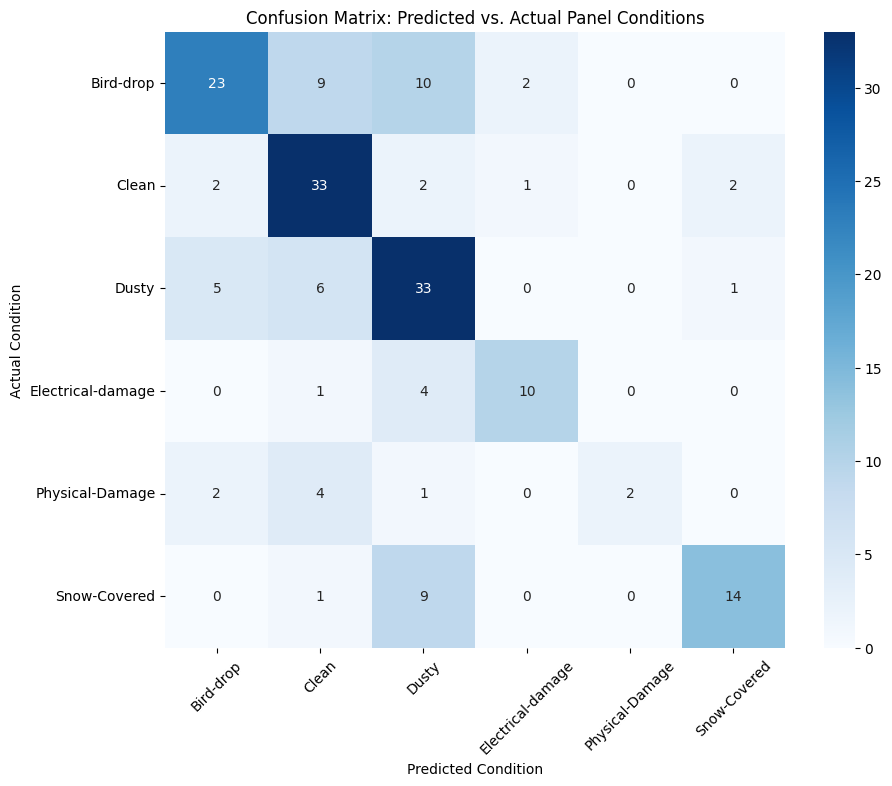

In [7]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true = np.concatenate([y for x, y in val_dataset], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

print("Generating predictions on the validation set...")
predictions = model.predict(val_dataset)
y_pred_classes = np.argmax(predictions, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Predicted vs. Actual Panel Conditions')
plt.ylabel('Actual Condition')
plt.xlabel('Predicted Condition')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Save the trained model
# model.save("solar_panel_model.keras")